<h2 style="background-color:#000033;padding:15px;font:bold 28px arial;color:#ccebff;border-radius:8px">
Proactive Maintenance â€” AI4I 2020 Dataset
</h2>

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

DATA_PATH   = "../data/ai4i2020.csv"
ASSETS_DIR  = "../assets"
os.makedirs(ASSETS_DIR, exist_ok=True)

<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
Dataset Description
</h3>

This synthetic dataset is modelled after an existing milling machine and consists of **10 000 data points** stored as rows with **14 features** in columns.

| # | Feature | Description |
|---|---------|-------------|
| 1 | UDI | Unique identifier 1â€“10 000 |
| 2 | Product ID | Letter (L/M/H) + variant serial number |
| 3 | Type | Product quality variant â€” L (50%), M (30%), H (20%) |
| 4 | Air temperature [K] | Random walk, Ïƒ = 2 K around 300 K |
| 5 | Process temperature [K] | Air temp + 10 K, Ïƒ = 1 K |
| 6 | Rotational speed [rpm] | Derived from 2860 W power + noise |
| 7 | Torque [Nm] | Normal distribution, Î¼ = 40 Nm, Ïƒ = 10 Nm |
| 8 | Tool wear [min] | Cumulative wear added per quality variant (H+5, M+3, L+2 min) |
| 9 | Machine failure | Binary label â€” 1 if any failure mode is active |

**Five independent failure modes (dropped before modelling â€” see note below):**
- **TWF** â€” Tool Wear Failure (tool replaced or failed at 200â€“240 min wear)
- **HDF** â€” Heat Dissipation Failure (temp diff < 8.6 K and speed < 1380 rpm)
- **PWF** â€” Power Failure (power outside 3500â€“9000 W)
- **OSF** â€” Overstrain Failure (tool wear Ã— torque exceeds variant threshold)
- **RNF** â€” Random Failure (0.1% chance per process)

<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
1. Load Data
</h3>

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print(f"Shape: {df.shape}")
df.info()

Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: f

<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
2. Data Preprocessing
</h3>

In [4]:
print("Null values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Null values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate rows: 0


In [5]:
print("Unique values per column:")
print(df.nunique())

Unique values per column:
UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64


In [6]:
print("Product type distribution:")
print(df['Type'].value_counts())

Product type distribution:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [7]:
print("Failure cases:")
print(df[df['Machine failure'] == 1].shape[0], "out of", len(df))
df[df['Machine failure'] == 1].head()

Failure cases:
339 out of 10000


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,0,0,1,0,0
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,1,0,0,0,0
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,0,0,0,1,0
161,162,L47341,L,298.3,308.1,1412,52.3,218,1,0,0,0,1,0


In [8]:
# Drop identifier columns â€” carry no predictive signal
df.drop(columns=['UDI', 'Product ID'], inplace=True)

<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
3. Feature Engineering
</h3>

In [9]:
# Temperature difference â€” directly referenced in the HDF failure rule (< 8.6 K)
df['temperature_difference'] = df['Process temperature [K]'] - df['Air temperature [K]']

# Mechanical power: P = Ï„ Ã— Ï‰ = Torque Ã— (RPM Ã— 2Ï€ / 60)
df['Mechanical Power [W]'] = np.round(
    (df['Torque [Nm]'] * df['Rotational speed [rpm]'] * 2 * np.pi) / 60, 4
)

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature_difference,Mechanical Power [W]
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.5906
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.7227
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.3875
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.5047
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.8166


<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
4. Statistical Description
</h3>

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.004930,2.000259,295.3000,298.3000,300.10000,301.5000,304.500
Process temperature [K],10000.0,310.005560,1.483734,305.7000,308.8000,310.10000,311.1000,313.800
Rotational speed [rpm],10000.0,1538.776100,179.284096,1168.0000,1423.0000,1503.00000,1612.0000,2886.000
Torque [Nm],10000.0,39.986910,9.968934,3.8000,33.2000,40.10000,46.8000,76.600
Tool wear [min],10000.0,107.951000,63.654147,0.0000,53.0000,108.00000,162.0000,253.000
Machine failure,10000.0,0.033900,0.180981,0.0000,0.0000,0.00000,0.0000,1.000
TWF,10000.0,0.004600,0.067671,0.0000,0.0000,0.00000,0.0000,1.000
HDF,10000.0,0.011500,0.106625,0.0000,0.0000,0.00000,0.0000,1.000
PWF,10000.0,0.009500,0.097009,0.0000,0.0000,0.00000,0.0000,1.000
OSF,10000.0,0.009800,0.098514,0.0000,0.0000,0.00000,0.0000,1.000


<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
5. Exploratory Data Analysis
</h3>

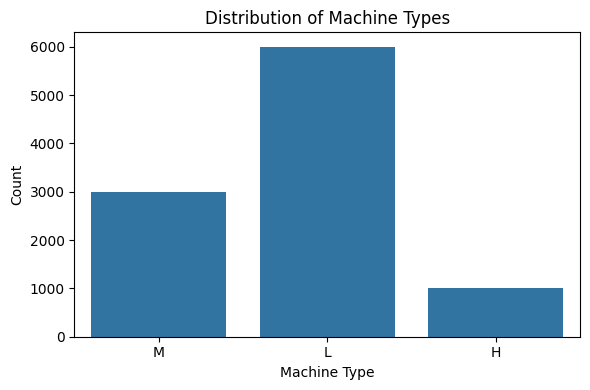

In [11]:
# 5.1 Distribution of machine types
plt.figure(figsize=(6, 4))
sns.countplot(x='Type', data=df)
plt.title('Distribution of Machine Types')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/eda_type_distribution.png", dpi=150)
plt.show()

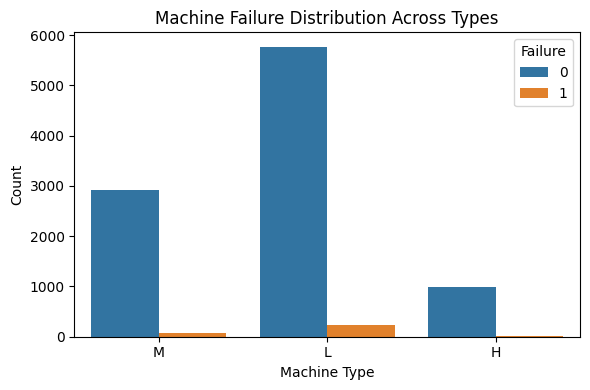

In [12]:
# 5.2 Failure distribution across product types
plt.figure(figsize=(6, 4))
sns.countplot(x='Type', hue='Machine failure', data=df)
plt.title('Machine Failure Distribution Across Types')
plt.xlabel('Machine Type')
plt.ylabel('Count')
plt.legend(title='Failure')
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/eda_failure_by_type.png", dpi=150)
plt.show()

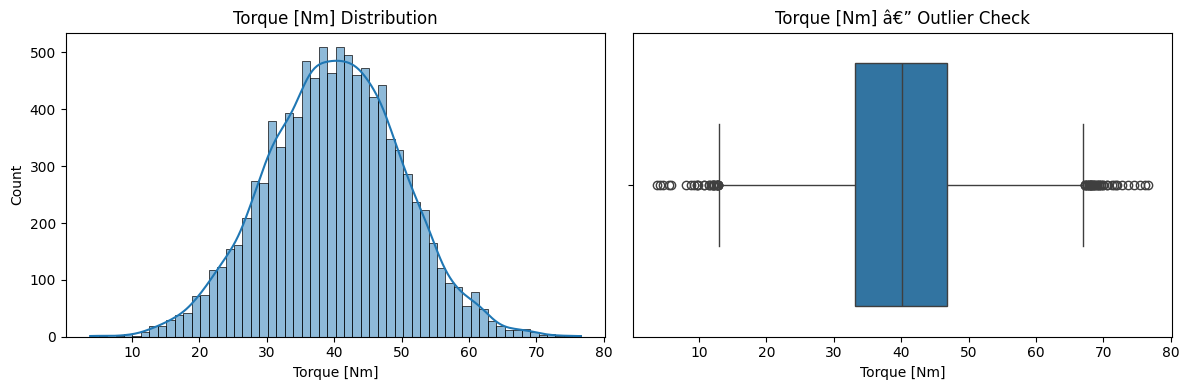

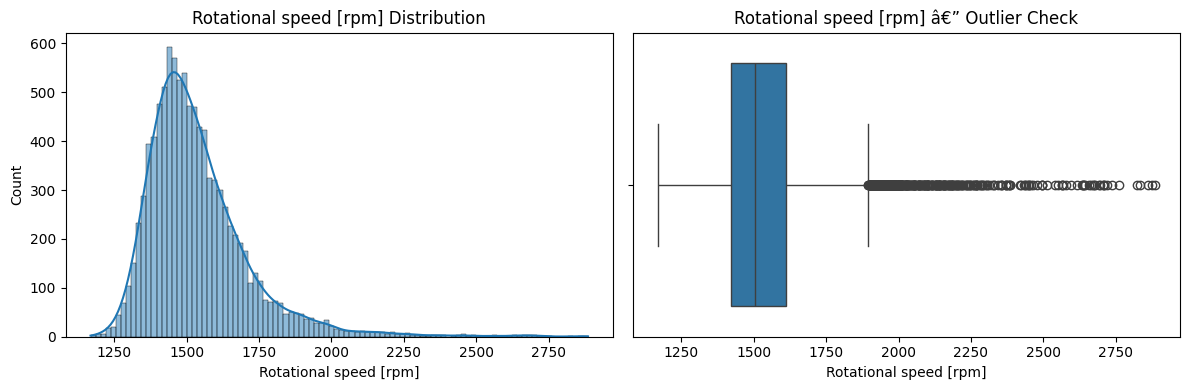

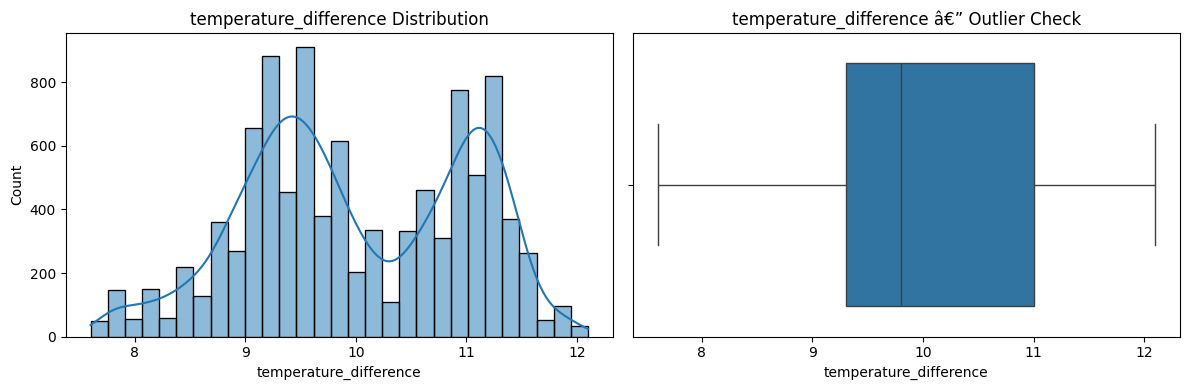

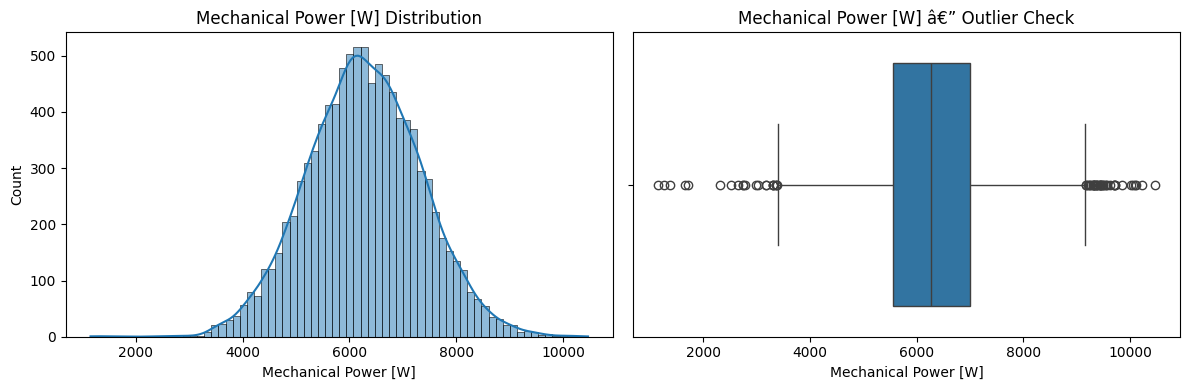

In [13]:
# 5.3 Feature distributions and outlier check
feature_cols = [
    'Torque [Nm]', 'Rotational speed [rpm]',
    'temperature_difference', 'Mechanical Power [W]'
]

for col in feature_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Distribution")
    sns.boxplot(data=df, x=col, ax=axes[1])
    axes[1].set_title(f"{col} â€” Outlier Check")
    plt.tight_layout()
    safe_name = col.replace('[', '').replace(']', '').replace(' ', '_').replace('/', '')
    plt.savefig(f"{ASSETS_DIR}/eda_dist_{safe_name}.png", dpi=150)
    plt.show()

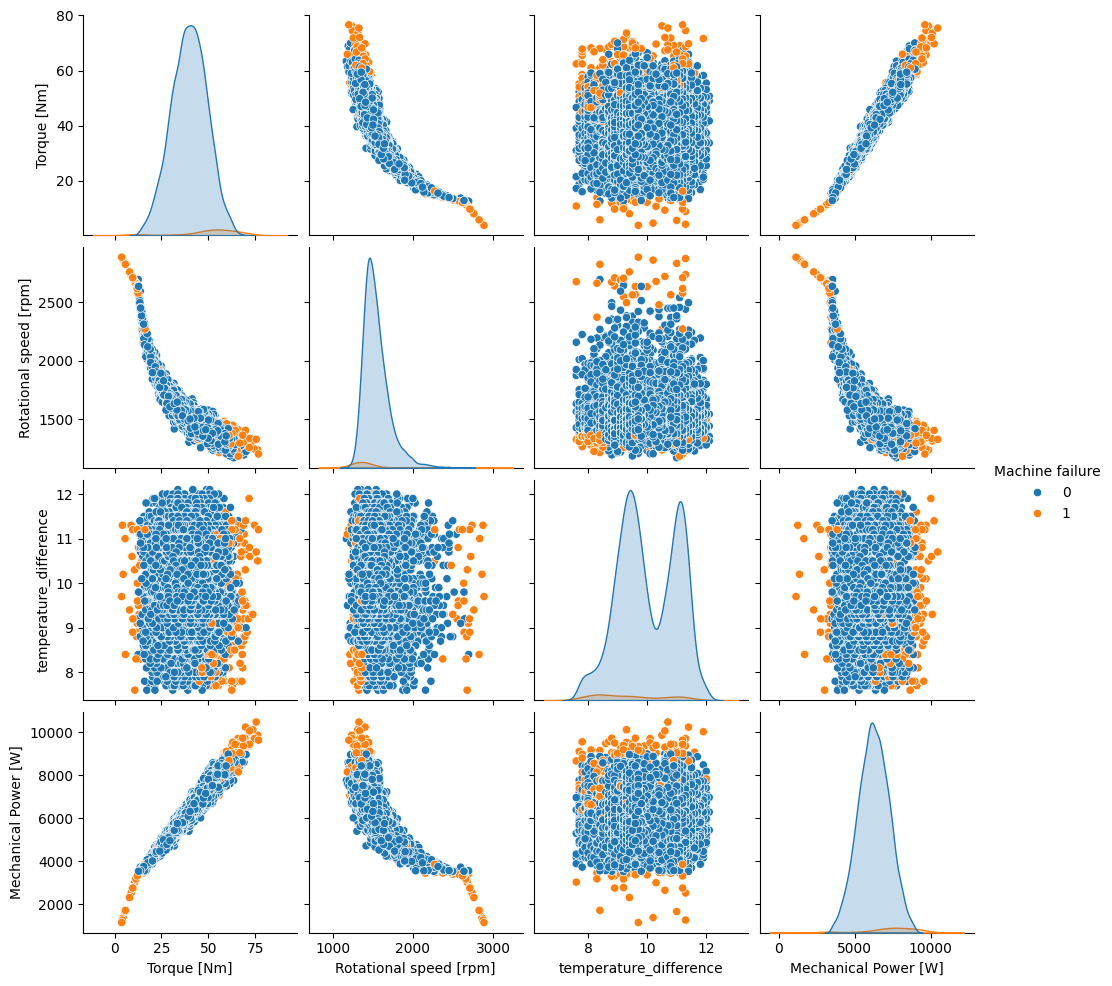

In [14]:
# 5.4 Pairplot â€” feature relationships coloured by failure label
pair_cols = [
    'Torque [Nm]', 'Rotational speed [rpm]',
    'temperature_difference', 'Mechanical Power [W]', 'Machine failure'
]
pair_fig = sns.pairplot(df[pair_cols], hue='Machine failure')
pair_fig.savefig(f"{ASSETS_DIR}/eda_pairplot.png", dpi=120)
plt.show()

<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
6. Correlation Analysis
</h3>

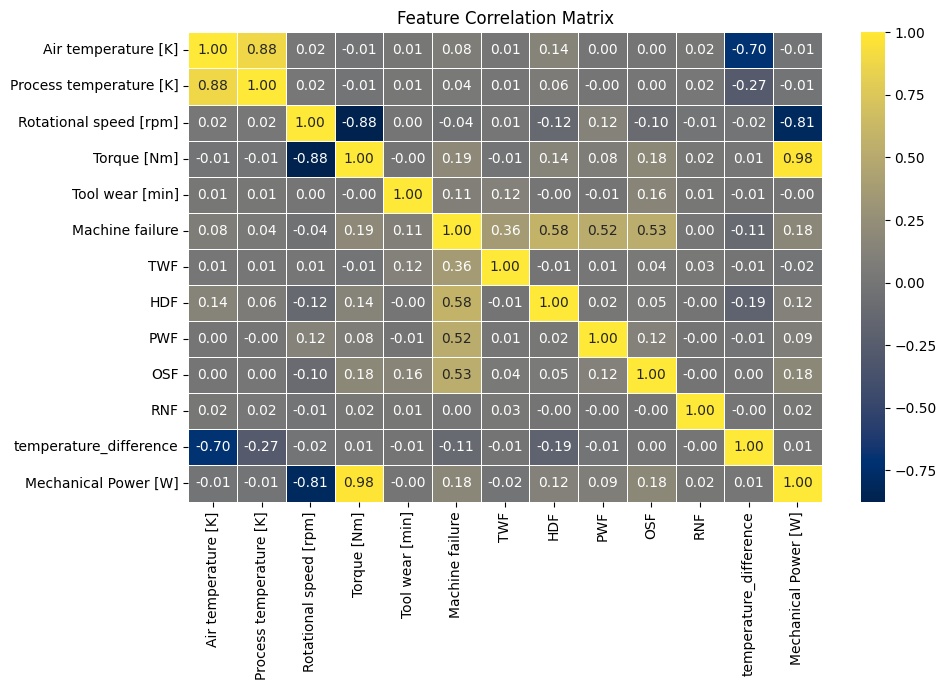

In [15]:
# Full feature correlation heatmap
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='cividis', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/corr_full_heatmap.png", dpi=150)
plt.show()

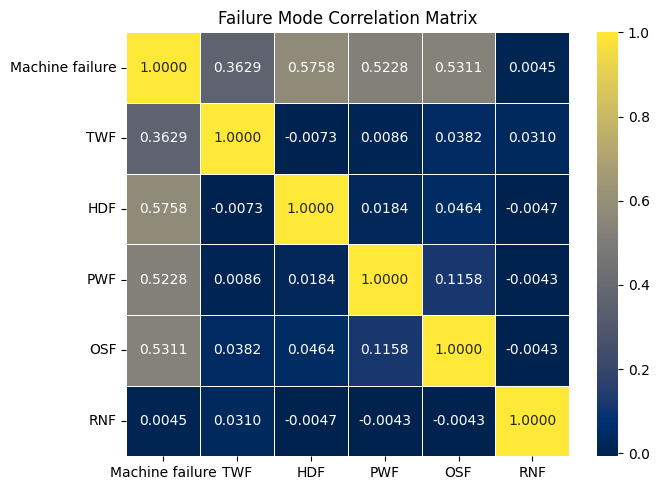

In [16]:
# Failure-mode correlation heatmap (named columns, not positional indices)
failure_cols = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
target_mat = df[failure_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(target_mat, annot=True, cmap='cividis', fmt='.4f', linewidths=0.5)
plt.title('Failure Mode Correlation Matrix')
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/corr_failure_modes.png", dpi=150)
plt.show()

**Why drop TWF, HDF, PWF, OSF, RNF?**

By dataset construction, `Machine failure = 1` if and only if at least one of these five flags equals 1.
Keeping them would be **direct target leakage**: the model would predict failure perfectly by reading the flags, learning nothing about the underlying sensor measurements.
They are also unavailable at real inference time â€” a sensor system does not know *which* failure mode occurred; it only has the physical readings.

In [17]:
df.drop(columns=['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], inplace=True)
df.sample(3)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,temperature_difference,Mechanical Power [W]
1515,M,298.2,308.9,1614,35.5,15,0,10.7,6000.1278
800,M,297.0,307.9,1882,24.2,97,0,10.9,4769.3984
7276,M,300.1,310.3,1350,48.8,50,0,10.2,6898.9375


<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
7. Encoding Categorical Columns
</h3>

In [18]:
import joblib
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# Persist encoder so the same mapping can be applied to new data at inference time
joblib.dump(le, f"{ASSETS_DIR}/label_encoder.joblib")
print("Type classes:", list(le.classes_), "â†’ encoded as", list(le.transform(le.classes_)))

Type classes: ['H', 'L', 'M'] â†’ encoded as [0, 1, 2]


<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
8. Train / Test Split
</h3>

The split happens **before** scaling and SMOTE so that test-set statistics never influence preprocessing fitted objects (scaler, SMOTE).

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Machine failure'])
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Class balance (train) â€” 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}")
print(f"Class balance (test)  â€” 0: {(y_test==0).sum()}  1: {(y_test==1).sum()}")

Train: 9000 samples  |  Test: 1000 samples
Class balance (train) â€” 0: 8695  1: 305
Class balance (test)  â€” 0: 966  1: 34


<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
9. Feature Scaling
</h3>

The scaler is **fit on training data only**, then applied to both splits.
Fitting on the full dataset would leak test-set distribution into the scaler.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Persist scaler for inference pipelines
joblib.dump(scaler, f"{ASSETS_DIR}/standard_scaler.joblib")
print("Scaler saved.")

pd.DataFrame(X_train_scaled, columns=X.columns).describe().T

Scaler saved.


,count,mean,std,min,25%,50%,75%,max
Type,9000.0,-3.789561e-17,1.000056,-2.006818,-0.335707,-0.335707,1.335403,1.335403
Air temperature [K],9000.0,-1.358123e-14,1.000056,-2.346277,-0.847456,0.051837,0.751287,2.250109
Process temperature [K],9000.0,-2.264677e-14,1.000056,-2.900084,-0.809126,0.067728,0.742230,2.563387
Rotational speed [rpm],9000.0,-1.113184e-16,1.000056,-2.065129,-0.644372,-0.198644,0.403088,7.506876
Torque [Nm],9000.0,4.579053e-17,1.000056,-3.639416,-0.674201,0.009307,0.682762,3.678132
Tool wear [min],9000.0,6.345541e-17,1.000056,-1.690306,-0.857964,-0.009917,0.853835,2.282951
temperature_difference,9000.0,-1.060485e-15,1.000056,-2.400411,-0.702486,-0.203096,0.995439,2.094097
Mechanical Power [W],9000.0,-2.127681e-16,1.000056,-4.818629,-0.670450,-0.009674,0.680775,3.929533


<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
10. Handling Class Imbalance â€” SMOTE
</h3>

SMOTE uses k-nearest neighbours to generate synthetic minority samples.
It is applied **only to the scaled training set** after the split, so the test set remains an honest hold-out of real, unseen data.

In [21]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Class distribution before SMOTE:", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution after  SMOTE:", Counter(y_train_res))

Class distribution before SMOTE: Counter({0: 8695, 1: 305})
Class distribution after  SMOTE: Counter({0: 8695, 1: 8695})


<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
11. Model Comparison
</h3>

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, SGDClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

candidate_models = {
    'Logistic Regression':    LogisticRegression(random_state=42),
    'Logistic Regression CV': LogisticRegressionCV(),
    'SGD':                    SGDClassifier(random_state=42),
    'Random Forest':          RandomForestClassifier(random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(random_state=42),
    'AdaBoost':               AdaBoostClassifier(random_state=42),
    'Bagging':                BaggingClassifier(random_state=42),
    'Decision Tree':          DecisionTreeClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'K-Nearest Neighbors':    KNeighborsClassifier(),
}

In [23]:
def compare_models(models, X_tr, X_te, y_tr, y_te):
    """Fit each model and return accuracy results sorted descending."""
    results = []
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, model.predict(X_te))
        results.append((name, acc))
    results.sort(key=lambda x: x[1], reverse=True)
    return results

In [24]:
comparison = compare_models(candidate_models, X_train_res, X_test_scaled, y_train_res, y_test)

print("Model Comparison (accuracy on held-out test set):")
for name, acc in comparison:
    print(f"  {name:<30} {acc:.6f}")

Model Comparison (accuracy on held-out test set):
  Random Forest                  0.982000
  Bagging                        0.978000
  Decision Tree                  0.969000
  Gradient Boosting              0.935000
  K-Nearest Neighbors            0.935000
  AdaBoost                       0.916000
  Support Vector Machine         0.916000
  Logistic Regression            0.856000
  Logistic Regression CV         0.855000
  SGD                            0.836000


<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
12. Final Model â€” Random Forest
</h3>

Random Forest yields the highest accuracy. We retrain it cleanly below.
Note: `class_weight` is omitted â€” the training set is already balanced via SMOTE.

In [25]:
RF = RandomForestClassifier(random_state=42)
RF.fit(X_train_res, y_train_res)

y_pred = RF.predict(X_test_scaled)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.6f}")

Test accuracy: 0.982000


<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
13. Detailed Evaluation
</h3>

In [26]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
)

def evaluate_final_model(model, X_te, y_te, model_name="Model"):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    print(f"--- {model_name} Classification Report ---\n")
    print(classification_report(y_te, y_pred))

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred)).plot(cmap='Blues', ax=ax)
    ax.set_title(f"{model_name} â€” Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/eval_confusion_matrix.png", dpi=150)
    plt.show()

    # ROC curve
    roc_auc = roc_auc_score(y_te, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_te, y_prob, ax=ax)
    ax.set_title(f"{model_name} â€” ROC Curve (AUC = {roc_auc:.2f})")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/eval_roc_curve.png", dpi=150)
    plt.show()

    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_te, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay(precision=precision, recall=recall).plot(ax=ax)
    ax.set_title(f"{model_name} â€” Precision-Recall Curve")
    plt.tight_layout()
    plt.savefig(f"{ASSETS_DIR}/eval_precision_recall.png", dpi=150)
    plt.show()

--- Random Forest Classification Report ---

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       966
           1       0.68      0.88      0.77        34

    accuracy                           0.98      1000
   macro avg       0.84      0.93      0.88      1000
weighted avg       0.99      0.98      0.98      1000



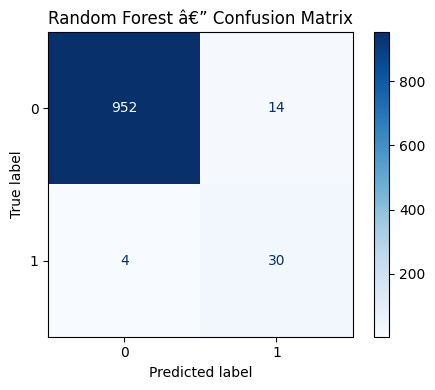

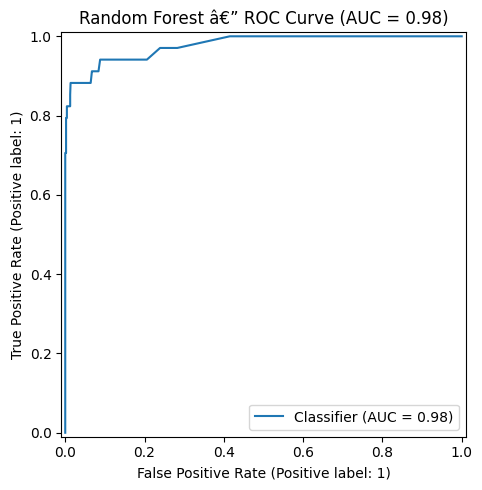

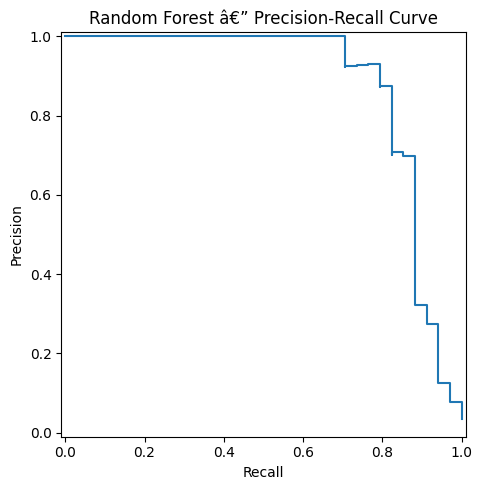

In [27]:
evaluate_final_model(RF, X_test_scaled, y_test, model_name="Random Forest")

<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
14. Feature Importance
</h3>

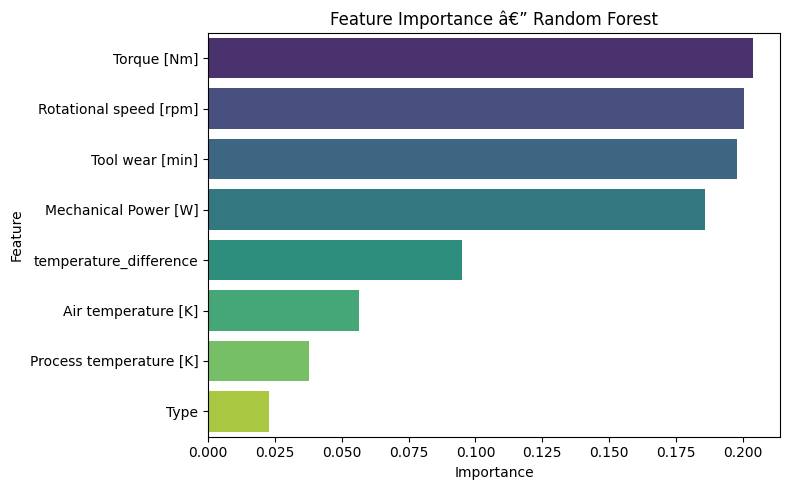

,Feature,Importance
4,Torque [Nm],0.203743
3,Rotational speed [rpm],0.200615
5,Tool wear [min],0.197915
7,Mechanical Power [W],0.185826
6,temperature_difference,0.094842
1,Air temperature [K],0.056315
2,Process temperature [K],0.037952
0,Type,0.022793


In [28]:
feature_imp_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': RF.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance â€” Random Forest')
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/feature_importance.png", dpi=150)
plt.show()

feature_imp_df

<h3 style="background-color:#000033;padding:15px;font:bold 24px arial;color:#ccebff;border-radius:8px">
15. Save Model
</h3>

In [29]:
joblib.dump(RF, f"{ASSETS_DIR}/random_forest_model.joblib")
print("Saved assets:")
for f in sorted(os.listdir(ASSETS_DIR)):
    size = os.path.getsize(os.path.join(ASSETS_DIR, f))
    print(f"  {f:<45} {size/1024:>8.1f} KB")

Saved assets:
  corr_failure_modes.png                            82.6 KB
  corr_full_heatmap.png                            197.6 KB
  eda_dist_Mechanical_Power_W.png                   54.8 KB
  eda_dist_Rotational_speed_rpm.png                 52.4 KB
  eda_dist_Torque_Nm.png                            49.4 KB
  eda_dist_temperature_difference.png               49.4 KB
  eda_failure_by_type.png                           25.6 KB
  eda_pairplot.png                                 566.8 KB
  eda_type_distribution.png                         21.9 KB
  eval_confusion_matrix.png                         24.1 KB
  eval_precision_recall.png                         24.2 KB
  eval_roc_curve.png                                39.2 KB
  feature_importance.png                            41.6 KB
  label_encoder.joblib                               0.5 KB
  random_forest_model.joblib                      7190.8 KB
  standard_scaler.joblib                             1.2 KB
